# Fake Speech Data Plots\n
\n
This notebook builds the 5 requested visualizations from `recordings/fake_speech_dataset.json`.

In [1]:
# Optional: install dependencies if missing (run once).\n
# Uncomment if needed:\n
# %pip install numpy matplotlib pandas ipywidgets\n

import json
from pathlib import Path
from collections import Counter

import numpy as np
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')

In [2]:
DATA_PATH = Path('recordings/fake_speech_dataset.json')
if not DATA_PATH.exists():
    raise FileNotFoundError(f'Could not find: {DATA_PATH}. Run generate_fake_speech_data.py first.')

data = json.loads(DATA_PATH.read_text(encoding='utf-8'))
recordings = data['recordings']
recording_ids = [r['recording_id'] for r in recordings]
filler_words = ['um', 'uh', 'you know', 'like']

print(f"Loaded {len(recordings)} recordings")
print(f"Total words: {data['total_words']}")
print(f"Total fillers: {data['total_filler_words']} ({data['overall_filler_percentage']}%)")

Loaded 8 recordings
Total words: 3151
Total fillers: 516 (16.38%)


## 1) Filler word position density per recording\n
\n
This shows whether fillers cluster near the start or are spread across each recording.

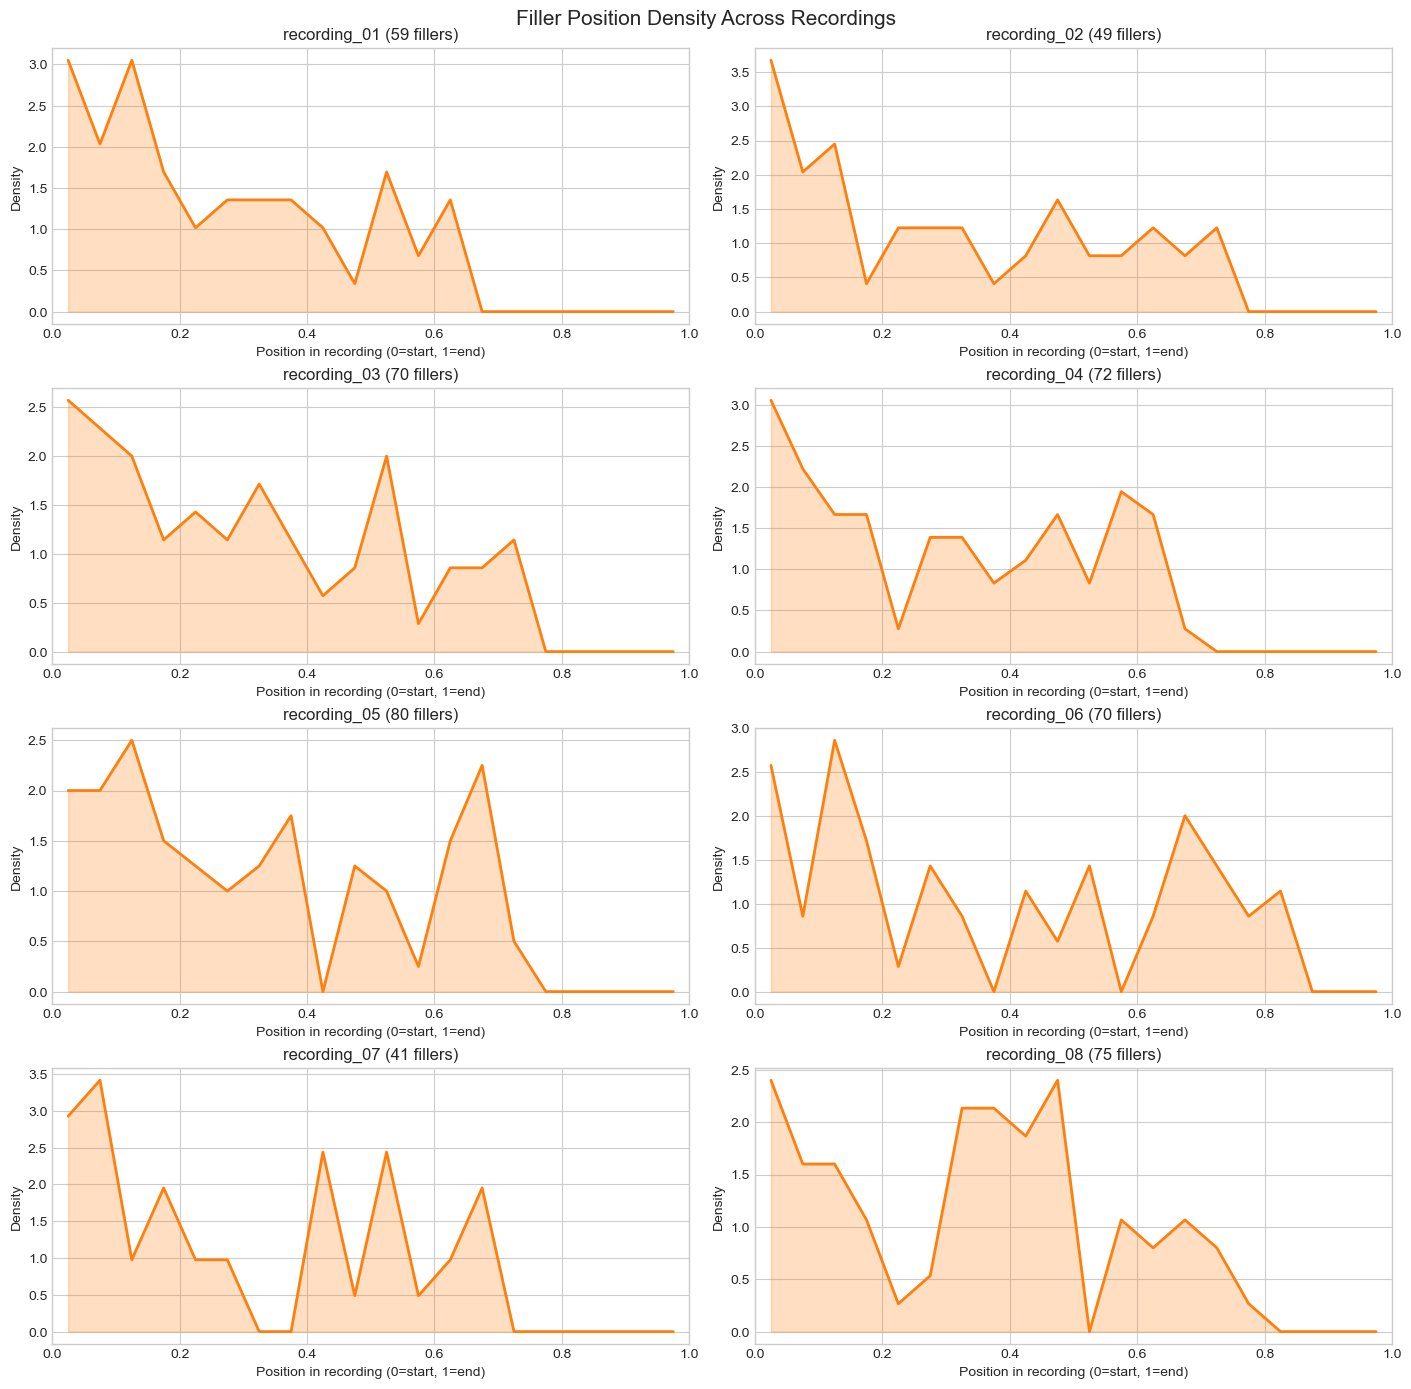

In [3]:
n = len(recordings)
cols = 2
rows = int(np.ceil(n / cols))
fig, axes = plt.subplots(rows, cols, figsize=(14, 3.4 * rows), constrained_layout=True)
axes = np.array(axes).reshape(-1)

for idx, rec in enumerate(recordings):
    ax = axes[idx]
    positions = [e['position_ratio'] for e in rec.get('filler_events', [])]
    if len(positions) > 1:
        bins = np.linspace(0, 1, 21)
        hist, edges = np.histogram(positions, bins=bins, density=True)
        centers = (edges[:-1] + edges[1:]) / 2
        ax.fill_between(centers, hist, alpha=0.25, color='tab:orange')
        ax.plot(centers, hist, linewidth=2, color='tab:orange')
    elif len(positions) == 1:
        ax.axvline(positions[0], color='tab:orange', linewidth=2)
    else:
        ax.text(0.5, 0.5, 'No fillers', ha='center', va='center', transform=ax.transAxes)

    ax.set_title(f"{rec['recording_id']} ({len(positions)} fillers)")
    ax.set_xlim(0, 1)
    ax.set_xlabel('Position in recording (0=start, 1=end)')
    ax.set_ylabel('Density')

for j in range(n, len(axes)):
    axes[j].axis('off')

plt.suptitle('Filler Position Density Across Recordings', y=1.01, fontsize=15)
plt.show()

## 2) Filler words over time (line plot)

Equivalent to Social Data Story-style plot: x=time, y=count, one line per filler word.

In [4]:
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
import matplotlib.pyplot as plt

selected_id = recording_ids[0]  # Change this to another recording_id
rec = next(r for r in recordings if r['recording_id'] == selected_id)
bins = rec['filler_time_bins']
times = [(b['time_start'] + b['time_end']) / 2 for b in bins]

# Create figure and axis
fig, ax = plt.subplots(figsize=(12, 5))

# Prepare data for all filler words
filler_data = {w: [b.get(w, 0) for b in bins] for w in filler_words}
total_data = [b.get('total', 0) for b in bins]

# Set up the plot limits
ax.set_xlim(min(times) - 1, max(times) + 1)
ax.set_ylim(0, max(max(filler_data.values(), key=max) + [max(total_data)]) * 1.1)
ax.set_xlabel('Time (seconds)')
ax.set_ylabel('Filler count per bin')
ax.set_title(f"Filler Words Over Time - {selected_id}")

# Store line objects
lines = {}
for w in filler_words:
    line, = ax.plot([], [], marker='o', linewidth=2, label=w)
    lines[w] = line

total_line, = ax.plot([], [], color='black', linewidth=2.5, linestyle='--', label='total')
ax.legend(loc='upper left')

# Animation function
def animate(frame):
    # frame goes from 0 to len(times)
    for w in filler_words:
        lines[w].set_data(times[:frame+1], filler_data[w][:frame+1])
    total_line.set_data(times[:frame+1], total_data[:frame+1])
    return list(lines.values()) + [total_line]

# Create animation
anim = FuncAnimation(fig, animate, frames=len(times), interval=200, blit=True, repeat=True)

# Display the animation
plt.close(fig)
HTML(anim.to_jshtml())

## 3) Pace over time (rolling 30-second WPM)

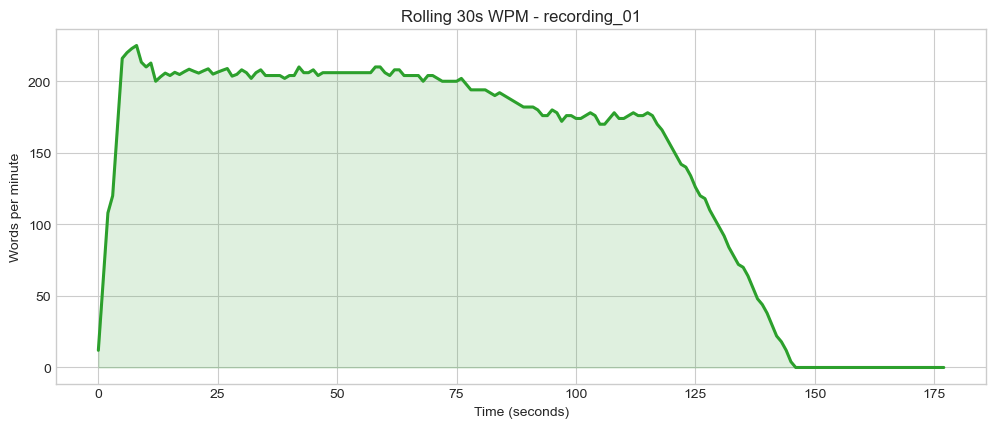

In [5]:
selected_id = recording_ids[0]  # Change as needed\n
rec = next(r for r in recordings if r['recording_id'] == selected_id)
rw = rec['rolling_wpm_30s']
times = [p['time'] for p in rw]
wpm = [p['wpm'] for p in rw]

plt.figure(figsize=(12, 4.6))
plt.plot(times, wpm, color='tab:green', linewidth=2.2)
plt.fill_between(times, wpm, alpha=0.15, color='tab:green')
plt.title(f"Rolling 30s WPM - {selected_id}")
plt.xlabel('Time (seconds)')
plt.ylabel('Words per minute')
plt.show()

## 4) Heatmap showing filler words across recordings

This view shows how often each filler word appears in each recording. Rows are sorted by overall frequency so the densest words stand out first.

In [ ]:
# Generate filler word summary for the heatmap
summary = data['filler_word_summary']
summary_map = {item['word']: item for item in summary}

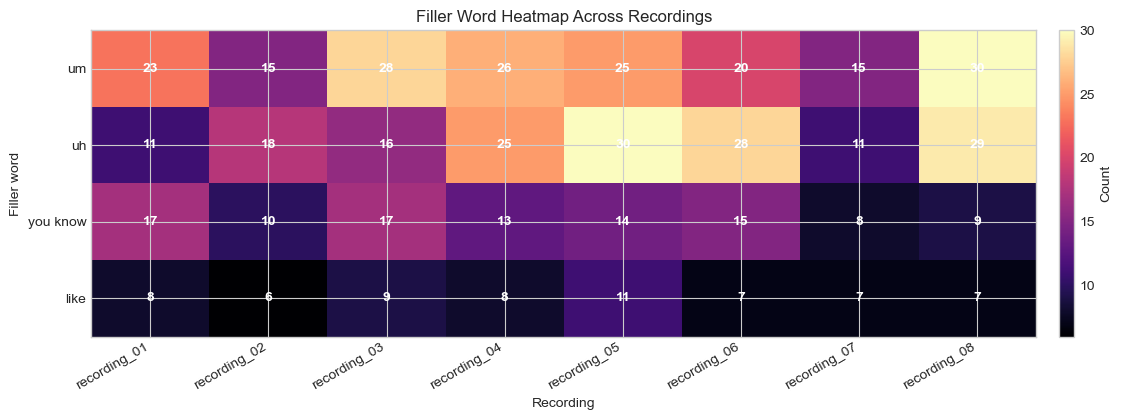

In [9]:
filler_order = sorted(summary_map.keys(), key=lambda w: summary_map[w]['count'], reverse=True)
heatmap = np.array(
    [
        [sum(1 for event in rec.get('filler_events', []) if event['word'] == word) for rec in recordings]
        for word in filler_order
    ],
    dtype=float,
)

fig, ax = plt.subplots(figsize=(12.5, max(3.8, 0.7 * len(filler_order) + 1.5)))
im = ax.imshow(heatmap, cmap='magma', aspect='auto')

ax.set_xticks(np.arange(len(recording_ids)))
ax.set_xticklabels(recording_ids, rotation=30, ha='right')
ax.set_yticks(np.arange(len(filler_order)))
ax.set_yticklabels(filler_order)
ax.set_xlabel('Recording')
ax.set_ylabel('Filler word')
ax.set_title('Filler Word Heatmap Across Recordings')

cbar = fig.colorbar(im, ax=ax, pad=0.02)
cbar.set_label('Count')

for row_idx in range(heatmap.shape[0]):
    for col_idx in range(heatmap.shape[1]):
        count = int(heatmap[row_idx, col_idx])
        if count:
            ax.text(
                col_idx,
                row_idx,
                str(count),
                ha='center',
                va='center',
                fontsize=10,
                fontweight='bold',
                color='white',
            )

ax.set_xlim(-0.5, len(recording_ids) - 0.5)
ax.set_ylim(len(filler_order) - 0.5, -0.5)
plt.tight_layout()
plt.show()

## 5) Pitch variation plots

Useful pair of plots:

1. Smoothed pitch contour for one recording (within-recording trend).
2. Median + range across recordings (between-recording comparison).

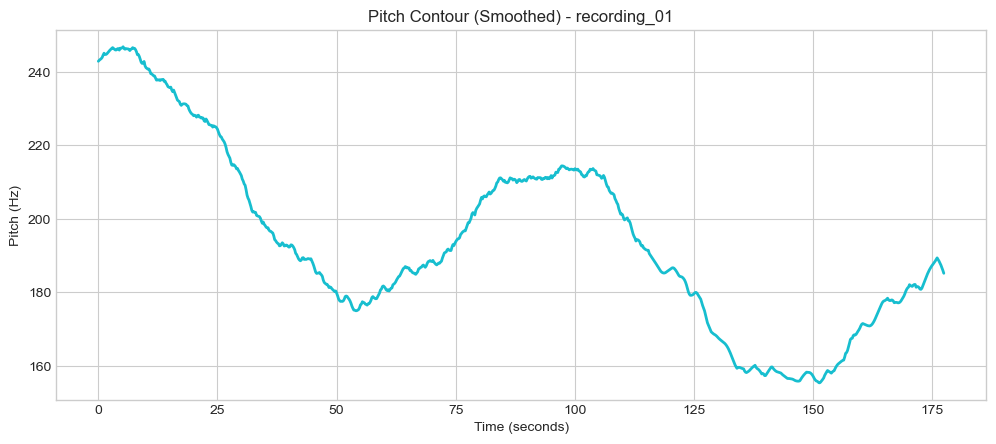

In [10]:
selected_id = recording_ids[0]  # Change as needed\n
rec = next(r for r in recordings if r['recording_id'] == selected_id)
track = rec['pitch_track']

times = np.array([p['time'] for p in track], dtype=float)
pitch = np.array([np.nan if p['pitch_hz'] is None else p['pitch_hz'] for p in track], dtype=float)

valid = ~np.isnan(pitch)
if valid.sum() == 0:
    raise ValueError('No voiced pitch values in selected recording.')

interp_pitch = np.interp(times, times[valid], pitch[valid])
window = 7
kernel = np.ones(window) / window
smooth_pitch = np.convolve(np.pad(interp_pitch, (window//2, window//2), mode='edge'), kernel, mode='valid')

plt.figure(figsize=(12, 4.8))
plt.plot(times, smooth_pitch, color='tab:cyan', linewidth=2)
plt.title(f"Pitch Contour (Smoothed) - {selected_id}")
plt.xlabel('Time (seconds)')
plt.ylabel('Pitch (Hz)')
plt.show()

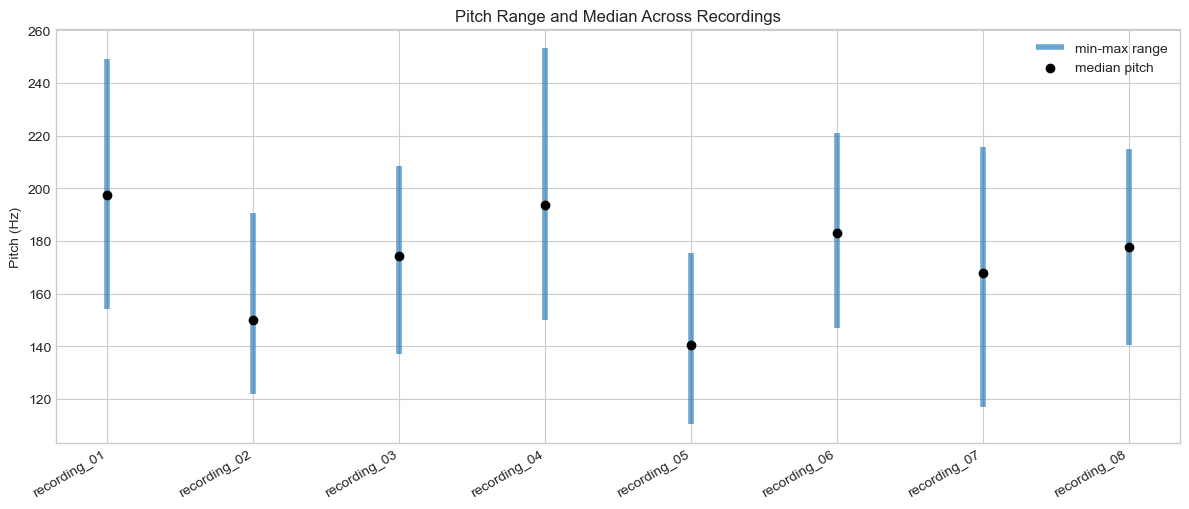

In [11]:
ids = [r['recording_id'] for r in recordings]
medians = [r['pitch_summary']['median_hz'] for r in recordings]
mins = [r['pitch_summary']['min_hz'] for r in recordings]
maxs = [r['pitch_summary']['max_hz'] for r in recordings]

x = np.arange(len(ids))
plt.figure(figsize=(12, 5.2))
plt.vlines(x, mins, maxs, color='tab:blue', alpha=0.65, linewidth=4, label='min-max range')
plt.scatter(x, medians, color='black', zorder=3, label='median pitch')
plt.xticks(x, ids, rotation=30, ha='right')
plt.ylabel('Pitch (Hz)')
plt.title('Pitch Range and Median Across Recordings')
plt.legend()
plt.tight_layout()
plt.show()

## Optional next steps\n
- Change `selected_id` in the relevant cells to inspect another recording.\n
- Regenerate fake data with another seed and rerun the notebook.\n
- Add export cells (`plt.savefig(...)`) for static report figures.

## 6) Filler count vs speaking pace

This scatter plot shows whether faster speaking correlates with more filler words, which could indicate nervousness or difficulty keeping up with thoughts.

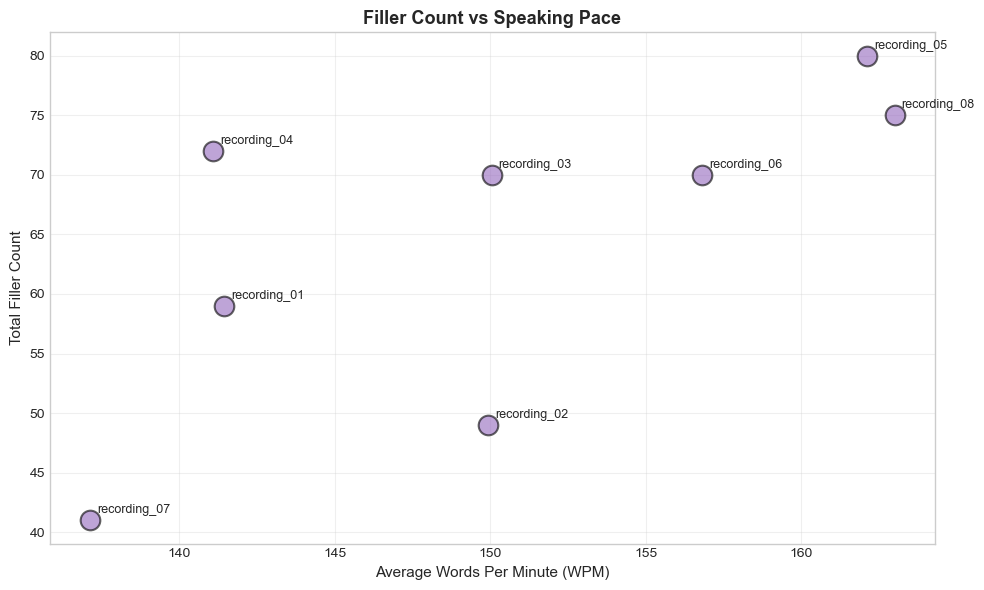

Correlation between WPM and filler count: 0.689


In [13]:
# Collect filler counts and average WPM for each recording
filler_counts = []
avg_wpm_values = []
rec_labels = []

for rec in recordings:
    total_fillers = len(rec.get('filler_events', []))
    filler_counts.append(total_fillers)
    
    # Calculate average WPM from rolling data
    rolling_wpm = rec.get('rolling_wpm_30s', [])
    if rolling_wpm:
        avg_wpm = np.mean([p['wpm'] for p in rolling_wpm])
    else:
        avg_wpm = 0
    avg_wpm_values.append(avg_wpm)
    rec_labels.append(rec['recording_id'])

plt.figure(figsize=(10, 6))
plt.scatter(avg_wpm_values, filler_counts, s=200, alpha=0.6, color='tab:purple', edgecolors='black', linewidth=1.5)

# Add labels to each point
for i, label in enumerate(rec_labels):
    plt.annotate(label, (avg_wpm_values[i], filler_counts[i]), 
                xytext=(5, 5), textcoords='offset points', fontsize=9)

plt.xlabel('Average Words Per Minute (WPM)', fontsize=11)
plt.ylabel('Total Filler Count', fontsize=11)
plt.title('Filler Count vs Speaking Pace', fontsize=13, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Calculate correlation if there are enough points
if len(filler_counts) > 2:
    correlation = np.corrcoef(avg_wpm_values, filler_counts)[0, 1]
    print(f"Correlation between WPM and filler count: {correlation:.3f}")